# Previsão de Violação de KPI — Classificação Binária

Modelo que, no momento da abertura do chamado, estima a probabilidade de que ele
venha a violar o prazo de KPI, permitindo alerta preventivo à operação.

## Definição do alvo

`fl_kpi_violado` — flag oficial de violação, medida no relógio de SLA (horário
comercial, com pausas). Filtro `fl_entrou_kpi = true`, que restringe aos chamados
elegíveis à medição: **25.600 registros, 248 violações (0,97%)**.

**Por que não `fl_kpi_violado_calc`:** essa coluna aplica a regra de tempo corrido
(duração > limite da prioridade). Contra a flag oficial ela tem Recall 99,6% e
precisão 6,8% — 3.398 alarmes falsos para 247 acertos. A diferença entre as duas é
o tempo de pausa do relógio de SLA. Treinar contra ela produziria um modelo que
prevê a regra errada.

## Features

Somente atributos conhecidos **no momento da abertura**. Excluídas todas as colunas
preenchidas após o desfecho (`duracao_seg`, `tempo_resolucao_*`, `status`,
`codigo_fechamento`, `tipo_solucao`, `pct_consumo_sla`, `fl_kpi_violado_calc`), que
causariam vazamento do alvo.

`sla_limite_seg` é redundante: só há duas prioridades no KPI (P2 = 4h, P3 = 12h) e o
limite é função exata de `prioridade_cod`.

`grupo_designado`, `categoria` e `subcategoria` são removidas por **teste de ablação**
(seção 4). São campos sujeitos a reclassificação durante o atendimento, o que as
tornaria vazamento; ao removê-las o PR-AUC **sobe** de 0,2229 para 0,2449 — a suspeita
é resolvida sem custo de desempenho.

## Validação

Divisão **temporal**: treino no passado, teste no período seguinte. A base tem quebra
de regime em setembro de 2025, causada pela expansão do escopo de monitoramento (CIs
monitorados passaram de ~1.200 para ~3.000). Um split aleatório vazaria o futuro para
o treino.

## Métrica principal

**PR-AUC (average precision)**. Com prevalência de 0,97%, o AUC-ROC é inflado pelo
tamanho da classe negativa — um modelo pouco útil ultrapassa 0,78 sem esforço. O
baseline do PR-AUC é a própria prevalência (0,0098), o que torna o ganho legível.

In [0]:
dbutils.widgets.text("catalog", "fiap_analytics")

CATALOG = dbutils.widgets.get("catalog")
S  = f"{CATALOG}.silver.incidentes"
ML = f"{CATALOG}.ml"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,
                                   StandardScaler, FunctionTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, precision_score,
                             recall_score, f1_score, confusion_matrix)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga e construção do alvo

In [0]:
df = spark.sql(f"""
SELECT
  numero, dt_abertura,
  prioridade_cod, grupo_designado, tipo_alerta, origem_abertura,
  produto, categoria, subcategoria, item_configuracao, prioridade_origem,
  fl_tem_incidente_pai, fl_automatico,
  hora_abertura, dia_semana_abertura,
  fl_kpi_violado
FROM {S}
WHERE fl_entrou_kpi = true
""").toPandas()

df['dt_abertura'] = pd.to_datetime(df['dt_abertura'])
df['y'] = df['fl_kpi_violado'].astype(int)

print(f"Registros : {len(df):,}")
print(f"Violacoes : {df.y.sum():,} ({100*df.y.mean():.2f}%)")
print(f"Periodo   : {df.dt_abertura.min().date()} a {df.dt_abertura.max().date()}")

Registros : 25,600
Violacoes : 248 (0.97%)
Periodo   : 2023-01-02 a 2025-12-31


## 2. Divisão temporal

Corte no percentil 80 das datas de abertura. O conjunto de teste cobre o período
posterior à quebra de regime de setembro de 2025, o que torna a avaliação um teste
de generalização sob mudança de contexto — mais exigente que um split aleatório.

In [0]:
corte = df['dt_abertura'].quantile(0.80)
tr = df[df.dt_abertura <= corte].copy()
te = df[df.dt_abertura >  corte].copy()

dias = (te.dt_abertura.max() - te.dt_abertura.min()).days + 1

print(f"Corte  : {corte.date()}")
print(f"Treino : {len(tr):,} linhas | {tr.y.sum()} violações ({100*tr.y.mean():.2f}%)")
print(f"Teste  : {len(te):,} linhas | {te.y.sum()} violações ({100*te.y.mean():.2f}%)")
print(f"Janela de teste: {dias} dias")

Corte  : 2025-10-01
Treino : 20,498 linhas | 198 violações (0.97%)
Teste  : 5,102 linhas | 50 violações (0.98%)
Janela de teste: 91 dias


## 3. Pré-processamento e modelos de referência

Cardinalidade limitada a 100 níveis por coluna categórica, definidos **apenas no
treino** — `item_configuracao` tem cerca de 3.000 valores distintos e estouraria o
limite de bins do HistGradientBoosting. Níveis não vistos são mapeados para `OUTROS`.

Dois modelos de referência: regressão logística com `class_weight='balanced'` (baseline
honesto, exigido para dar sentido ao ganho) e HistGradientBoosting com todas as
features.

In [0]:
CATEGORICAS = ['grupo_designado','tipo_alerta','origem_abertura','produto',
               'categoria','subcategoria','item_configuracao',
               'prioridade_origem','dia_semana_abertura']
NUMERICAS   = ['prioridade_cod','hora_abertura']
BOOLEANAS   = ['fl_tem_incidente_pai','fl_automatico']
COLS        = CATEGORICAS + NUMERICAS + BOOLEANAS

niveis = {c: sorted(set(tr[c].value_counts().head(100).index) | {'OUTROS','AUSENTE'})
          for c in CATEGORICAS}

def preparar(d):
    d = d.copy()
    for c in CATEGORICAS:
        d[c] = d[c].fillna('AUSENTE').astype(str)
        d[c] = d[c].where(d[c].isin(niveis[c]), 'OUTROS')
    for c in BOOLEANAS:
        d[c] = d[c].fillna(False).astype(int)
    for c in NUMERICAS:
        d[c] = d[c].fillna(-1)
    return d

tr_p, te_p = preparar(tr), preparar(te)

enc = OrdinalEncoder(categories=[niveis[c] for c in CATEGORICAS],
                     handle_unknown='use_encoded_value', unknown_value=-1)

X_tr = np.hstack([enc.fit_transform(tr_p[CATEGORICAS]),
                  tr_p[NUMERICAS + BOOLEANAS].values]).astype('float64')
X_te = np.hstack([enc.transform(te_p[CATEGORICAS]),
                  te_p[NUMERICAS + BOOLEANAS].values]).astype('float64')

y_tr, y_te = tr_p.y.values, te_p.y.values
mascara_cat = [True]*len(CATEGORICAS) + [False]*(len(NUMERICAS)+len(BOOLEANAS))

print(f"Features: {X_tr.shape[1]} ({len(CATEGORICAS)} categóricas)")

Features: 13 (9 categóricas)


In [0]:
# Baseline: regressão logística com one-hot
base = Pipeline([
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20,
                              sparse_output=False), CATEGORICAS),
        ('num', StandardScaler(), NUMERICAS + BOOLEANAS)])),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000,
                               random_state=RANDOM_STATE))
])
base.fit(tr_p[COLS], y_tr)
prob_base = base.predict_proba(te_p[COLS])[:, 1]

# Gradient boosting com todas as features
gbm = HistGradientBoostingClassifier(
    categorical_features=mascara_cat, class_weight='balanced',
    max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=30,
    random_state=RANDOM_STATE)
gbm.fit(X_tr, y_tr)
prob_gbm = gbm.predict_proba(X_te)[:, 1]

print(f"Iterações até parada antecipada: {gbm.n_iter_}")

Iterações até parada antecipada: 43


Logística (baseline)     PR-AUC=0.2034  ROC-AUC=0.789
HistGradientBoosting     PR-AUC=0.2229  ROC-AUC=0.796
Aleatório                PR-AUC=0.0098  ROC-AUC=0.500


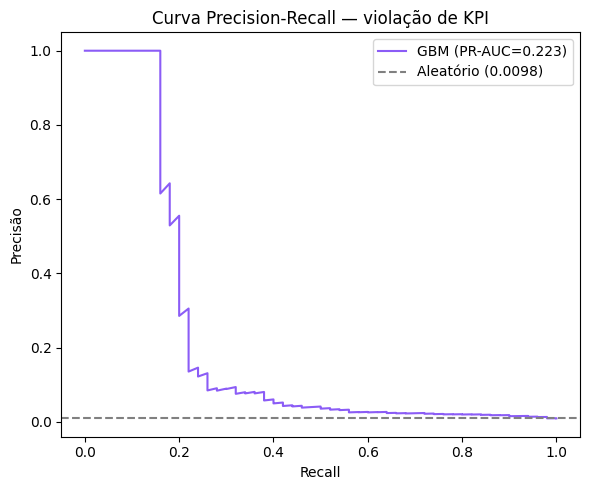

In [0]:
prevalencia = y_te.mean()

for nome, p_ in [('Logística (baseline)', prob_base),
                 ('HistGradientBoosting', prob_gbm)]:
    print(f"{nome:24s} PR-AUC={average_precision_score(y_te, p_):.4f}  "
          f"ROC-AUC={roc_auc_score(y_te, p_):.3f}")
print(f"{'Aleatório':24s} PR-AUC={prevalencia:.4f}  ROC-AUC=0.500")

prec, rec, _ = precision_recall_curve(y_te, prob_gbm)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(rec, prec, color='#8B5CF6',
        label=f'GBM (PR-AUC={average_precision_score(y_te, prob_gbm):.3f})')
ax.axhline(prevalencia, ls='--', color='gray', label=f'Aleatório ({prevalencia:.4f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precisão')
ax.set_title('Curva Precision-Recall — violação de KPI')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Ablação — as variáveis de alta cardinalidade ajudam ou atrapalham?

A importância por permutação sobre o modelo completo aponta `subcategoria`,
`categoria` e `grupo_designado` no topo — justamente os três campos passíveis de
reclassificação durante o atendimento, o que os tornaria vazamento do alvo.

Nota metodológica: importância por permutação mede o quanto o modelo **depende** de
uma coluna, não o quanto ela **ajuda**. O teste abaixo remove cada conjunto e remede
o PR-AUC, que é o que decide.

In [0]:
for fora in [['grupo_designado'],
             ['categoria','subcategoria'],
             ['grupo_designado','categoria','subcategoria']]:
    idx = [COLS.index(c) for c in fora]
    Xa, Xb = np.delete(X_tr, idx, axis=1), np.delete(X_te, idx, axis=1)
    mc = [m for j, m in enumerate(mascara_cat) if j not in idx]
    g = HistGradientBoostingClassifier(
        categorical_features=mc, class_weight='balanced',
        max_iter=400, learning_rate=0.05, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=30,
        random_state=RANDOM_STATE).fit(Xa, y_tr)
    print(f"sem {str(fora):<48} PR-AUC="
          f"{average_precision_score(y_te, g.predict_proba(Xb)[:,1]):.4f}")

sem ['grupo_designado']                              PR-AUC=0.1782
sem ['categoria', 'subcategoria']                    PR-AUC=0.2531
sem ['grupo_designado', 'categoria', 'subcategoria'] PR-AUC=0.2449


Remover as três **melhora** o PR-AUC. Com ~3.000 níveis de item de configuração e
centenas de subcategorias, essas colunas produzem memorização no treino que não
generaliza para o período seguinte. O modelo final fica mais simples e a suspeita de
vazamento desaparece junto.

## 5. Modelo final

Construído como `Pipeline`, com o pré-processamento **dentro** do artefato. Isso evita
a falha silenciosa de servir o modelo com encoders desalinhados — se o mapeamento de
categorias não acompanhar o modelo, a inferência produz resultado errado sem erro.

In [0]:
FORA   = ['grupo_designado','categoria','subcategoria']
CAT_F  = [c for c in CATEGORICAS if c not in FORA]
COLS_F = CAT_F + NUMERICAS + BOOLEANAS


def construir_modelo(df_treino):
    """Devolve um Pipeline nao treinado, com niveis derivados apenas de df_treino."""
    niv = {c: sorted(set(df_treino[c].value_counts().head(100).index)
                     | {'OUTROS','AUSENTE'}) for c in CAT_F}

    def capar(d):
        d = d.copy()
        for c in CAT_F:
            d[c] = d[c].fillna('AUSENTE').astype(str)
            d[c] = d[c].where(d[c].isin(niv[c]), 'OUTROS')
        for c in BOOLEANAS:
            d[c] = d[c].fillna(False).astype(int)
        for c in NUMERICAS:
            d[c] = d[c].fillna(-1)
        return d[COLS_F]

    mc = [True]*len(CAT_F) + [False]*(len(NUMERICAS)+len(BOOLEANAS))

    return Pipeline([
        ('capar', FunctionTransformer(capar, validate=False)),
        ('enc',   ColumnTransformer([
            ('cat', OrdinalEncoder(categories=[niv[c] for c in CAT_F],
                                   handle_unknown='use_encoded_value',
                                   unknown_value=-1), CAT_F),
            ('num', 'passthrough', NUMERICAS + BOOLEANAS)])),
        ('clf',   HistGradientBoostingClassifier(
            categorical_features=mc, class_weight='balanced',
            max_iter=400, learning_rate=0.05, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=30,
            random_state=RANDOM_STATE))
    ])


modelo = construir_modelo(tr).fit(tr[COLS_F], y_tr)
prob   = modelo.predict_proba(te[COLS_F])[:, 1]

print(f"Features : {len(COLS_F)} — {COLS_F}")
print(f"PR-AUC   : {average_precision_score(y_te, prob):.4f} "
      f"(baseline {prevalencia:.4f})")
print(f"ROC-AUC  : {roc_auc_score(y_te, prob):.3f}")

Features : 10 — ['tipo_alerta', 'origem_abertura', 'produto', 'item_configuracao', 'prioridade_origem', 'dia_semana_abertura', 'prioridade_cod', 'hora_abertura', 'fl_tem_incidente_pai', 'fl_automatico']
PR-AUC   : 0.2449 (baseline 0.0098)
ROC-AUC  : 0.721


## 6. Ponto de operação — quantos alertas a operação consegue absorver?

Com 0,98% de prevalência, o limiar padrão de 0,5 não tem sentido operacional. O limiar
é escolhido pelo **orçamento de alertas**: dado quantos chamados por dia a equipe
consegue revisar, qual precisão e qual recall isso compra.

In [0]:
print(f"{'Alertas/dia':>12} {'N':>6} {'Precisão':>9} {'Recall':>8} {'Pegou':>7}")
for apd in [0.25, 0.5, 1, 2, 3, 5]:
    n   = min(int(apd * dias), len(prob) - 1)
    lim = np.sort(prob)[::-1][n]
    p   = (prob >= lim).astype(int)
    print(f"{apd:>12} {p.sum():>6} "
          f"{precision_score(y_te, p, zero_division=0):>9.3f} "
          f"{recall_score(y_te, p):>8.3f} {int((p & y_te).sum()):>7}")

ALERTAS_DIA = 0.25
n      = min(int(ALERTAS_DIA * dias), len(prob) - 1)
limiar = np.sort(prob)[::-1][n]
pred   = (prob >= limiar).astype(int)

print(f"\nEscolhido: {ALERTAS_DIA}/dia | limiar={limiar:.4f} | "
      f"{pred.sum()} alertas em {dias} dias")
print(f"Precisão={precision_score(y_te, pred, zero_division=0):.3f} | "
      f"Recall={recall_score(y_te, pred):.3f} | F1={f1_score(y_te, pred):.3f}")
print(confusion_matrix(y_te, pred))

 Alertas/dia      N  Precisão   Recall   Pegou
        0.25     23     0.565    0.260      13
         0.5     46     0.348    0.320      16
           1     92     0.185    0.340      17
           2    183     0.109    0.400      20
           3    274     0.084    0.460      23
           5    458     0.050    0.460      23

Escolhido: 0.25/dia | limiar=0.8958 | 23 alertas em 91 dias
Precisão=0.565 | Recall=0.260 | F1=0.356
[[5042   10]
 [  37   13]]


## 7. Importância das variáveis

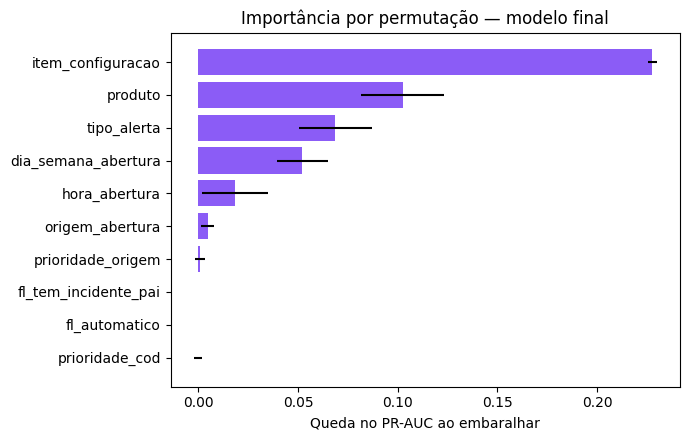

In [0]:
imp = permutation_importance(modelo, te[COLS_F], y_te, n_repeats=10,
                             random_state=RANDOM_STATE,
                             scoring='average_precision')
ordem = np.argsort(imp.importances_mean)[::-1]
nomes = np.array(COLS_F)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.barh(range(len(ordem)), imp.importances_mean[ordem][::-1],
        xerr=imp.importances_std[ordem][::-1], color='#8B5CF6')
ax.set_yticks(range(len(ordem))); ax.set_yticklabels(nomes[ordem][::-1])
ax.set_xlabel('Queda no PR-AUC ao embaralhar')
ax.set_title('Importância por permutação — modelo final')
plt.tight_layout(); plt.show()

## 8. Robustez ao ponto de corte

O resultado acima vem de um único corte temporal. Esta seção repete o treino em
quatro cortes distintos para verificar se o desempenho é estável ou se depende de
onde se cortou. Cada corte recalcula os níveis das categóricas a partir do seu
próprio treino, sem contaminação.

In [0]:
print(f"{'q':>5} {'corte':>12} {'teste':>8} {'viol.':>6} {'PR-AUC':>8}")
resultados = []
for q in [0.70, 0.75, 0.80, 0.85]:
    c    = df['dt_abertura'].quantile(q)
    a, b = df[df.dt_abertura <= c], df[df.dt_abertura > c]
    if b.y.sum() < 20:
        print(f"{q:>5} {str(c.date()):>12}  teste com apenas {b.y.sum()} violações — ignorado")
        continue
    m  = construir_modelo(a).fit(a[COLS_F], a.y.values)
    pr = average_precision_score(b.y.values, m.predict_proba(b[COLS_F])[:, 1])
    resultados.append(pr)
    print(f"{q:>5} {str(c.date()):>12} {len(b):>8,} {b.y.sum():>6} {pr:>8.4f}")

if resultados:
    print(f"\nFaixa: {min(resultados):.4f} a {max(resultados):.4f} | "
          f"média {np.mean(resultados):.4f} | desvio {np.std(resultados):.4f}")

    q        corte    teste  viol.   PR-AUC
  0.7   2025-08-28    7,655     62   0.2022
 0.75   2025-09-16    6,377     57   0.2018
  0.8   2025-10-01    5,102     50   0.2449
 0.85   2025-10-20    3,818     43   0.2708

Faixa: 0.2018 a 0.2708 | média 0.2299 | desvio 0.0294


## 9. Persistência e registro no MLflow

As faixas de risco são ancoradas no orçamento operacional, não em cortes arbitrários
de probabilidade: `1_ALTO` é o topo correspondente a 0,25 alerta/dia, `2_ATENCAO` vai
até 2 alertas/dia (monitoramento reforçado, sem disparo automático) e o restante é
`3_BAIXO`.

In [0]:
import mlflow, mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

lim_alto    = limiar
lim_atencao = np.sort(prob)[::-1][min(int(2*dias), len(prob)-1)]

saida = te[['numero','dt_abertura','prioridade_cod','produto']].copy()
saida['prob_violacao'] = prob
saida['alerta']        = pred
saida['violou_real']   = y_te
saida['faixa'] = np.select([prob >= lim_alto, prob >= lim_atencao],
                           ['1_ALTO', '2_ATENCAO'], default='3_BAIXO')

spark.createDataFrame(saida).write.mode('overwrite') \
     .option('overwriteSchema','true').saveAsTable(f"{ML}.previsao_kpi")
print(f"Gravado: {ML}.previsao_kpi ({len(saida):,} linhas)")

usuario = spark.sql('SELECT current_user()').first()[0]
mlflow.set_experiment(f"/Users/{usuario}/fiap_previsao_kpi")

# float64 evita erro de schema caso cheguem nulos nas colunas inteiras na inferencia
exemplo    = te[COLS_F].head(5).astype({'prioridade_cod':'float64',
                                        'hora_abertura':'float64'})
assinatura = infer_signature(exemplo, modelo.predict_proba(exemplo))

with mlflow.start_run(run_name="gbm_kpi_violado_final") as run:
    mlflow.log_params({
        'modelo':      'HistGradientBoosting (Pipeline)',
        'alvo':        'fl_kpi_violado',
        'split':       'temporal',
        'corte':       str(corte.date()),
        'features':    ','.join(COLS_F),
        'removidas':   ','.join(FORA),
        'limiar':      round(float(limiar), 4),
        'alertas_dia': ALERTAS_DIA})
    mlflow.log_metrics({
        'pr_auc':              average_precision_score(y_te, prob),
        'pr_auc_logistica':    average_precision_score(y_te, prob_base),
        'pr_auc_gbm_completo': average_precision_score(y_te, prob_gbm),
        'pr_auc_baseline':     float(prevalencia),
        'roc_auc':             roc_auc_score(y_te, prob),
        'precisao':            precision_score(y_te, pred, zero_division=0),
        'recall':              recall_score(y_te, pred),
        'f1':                  f1_score(y_te, pred),
        'n_violacoes_teste':   int(y_te.sum())})

    # pyfunc_predict_fn: sem isso, o flavor pyfunc chama predict() e devolve 0/1
    # no limiar interno de 0,5 -- com prevalencia de 0,98% isso nunca alerta.
    mlflow.sklearn.log_model(modelo, name="modelo",
                             signature=assinatura, input_example=exemplo,
                             pyfunc_predict_fn="predict_proba")
    run_id = run.info.run_id

print(f"Run registrado: {run_id}")

Gravado: fiap_analytics.ml.previsao_kpi (5,102 linhas)


🔗 View Logged Model at: https://dbc-798c0991-6bbc.cloud.databricks.com/ml/experiments/280544283419085/models/m-b245e6dff0c245eaaf3b9eaae02c7775?o=2857185547527844


Run registrado: 755fb73dd9284b5ea3bfe73347882fd9


In [0]:
# Registro no Unity Catalog com alias @champion (mesmo padrao da ANN)
mlflow.set_registry_uri("databricks-uc")

NOME_UC = f"{CATALOG}.ml.previsao_kpi_gbm"
versao  = mlflow.register_model(f"runs:/{run_id}/modelo", NOME_UC)

MlflowClient().set_registered_model_alias(NOME_UC, "champion", versao.version)
print(f"Registrado: {NOME_UC} versao {versao.version} -> @champion")

Successfully registered model 'fiap_analytics.ml.previsao_kpi_gbm'.
2026/09/09 00:15:33 WARNING mlflow.tracking._model_registry.fluent: Run with id 755fb73dd9284b5ea3bfe73347882fd9 has no artifacts at artifact path 'modelo', registering model based on models:/m-b245e6dff0c245eaaf3b9eaae02c7775 instead


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '1' of model 'fiap_analytics.ml.previsao_kpi_gbm': https://dbc-798c0991-6bbc.cloud.databricks.com/explore/data/models/fiap_analytics/ml/previsao_kpi_gbm/version/1?o=2857185547527844


Registrado: fiap_analytics.ml.previsao_kpi_gbm versao 1 -> @champion


### Calibração por faixa

A taxa de violação real deve crescer monotonicamente de `3_BAIXO` para `1_ALTO`.
Se crescer, as faixas estão calibradas e servem diretamente como visual de risco
no Power BI.

In [0]:
display(spark.sql(f"""
SELECT faixa,
       COUNT(*)                            AS qtd,
       SUM(violou_real)                    AS violacoes,
       ROUND(100.0*AVG(violou_real), 2)    AS taxa_pct
FROM {ML}.previsao_kpi
GROUP BY faixa
ORDER BY faixa
"""))

faixa,qtd,violacoes,taxa_pct
1_ALTO,23,13,56.52
2_ATENCAO,160,7,4.38
3_BAIXO,4919,30,0.61


## 10. Resultados e limitações

| Modelo | PR-AUC | ROC-AUC |
|---|---|---|
| Aleatório (prevalência) | 0,0098 | 0,500 |
| Regressão logística | 0,2034 | 0,789 |
| HistGB, todas as features | 0,2229 | 0,796 |
| **HistGB final (10 features)** | **0,2449** | 0,721 |

O modelo final concentra risco muito acima da taxa base: com prevalência de 0,98% no
período de teste, o topo do ranking atinge **56,5% de precisão** — cerca de 58 vezes a
taxa base.

**Sobre a queda do ROC-AUC (0,796 → 0,721) com PR-AUC maior.** As duas métricas pesam
regiões distintas do ranking. O ROC-AUC avalia a ordenação completa, dominada pelos
5.052 negativos; o PR-AUC concentra-se no topo. Remover as colunas de alta
cardinalidade degradou o meio da lista e melhorou o topo — exatamente a região usada
pelo alerta, que classifica apenas 23 chamados em 91 dias. Para este caso de uso, o
PR-AUC é a métrica correta e o ROC-AUC é secundário.

**Ponto de operação escolhido: 0,25 alerta/dia.** Um chamado a cada quatro dias entra
na fila de revisão e mais da metade deles viola de fato o KPI. Captura 26% das
violações do período (13 de 50) que passariam despercebidas. Dobrar o volume de
alertas para 0,5/dia compra apenas 3 violações adicionais e derruba a precisão de
56,5% para 34,8% — o ganho não compensa.

### Limitações

1. **50 violações no conjunto de teste.** Toda métrica carrega margem larga. A
   diferença entre 0,2229 e 0,2449 que motivou a remoção das três colunas está dentro
   do ruído amostral — o argumento não é "melhorou", é "não piorou e eliminou a dúvida
   de vazamento".

2. **Dependência do corte temporal.** Medida diretamente na seção 8: PR-AUC entre
   0,2018 e 0,2708 em quatro cortes (média 0,2299, desvio 0,0294), sempre entre 20x
   e 28x o baseline. Os cortes de 0,70 e 0,75 posicionam o conjunto de teste antes da
   expansão do escopo de monitoramento e o desempenho se mantém, indicando que o
   modelo generaliza através da quebra de regime.

3. **Sem reavaliação ao longo do ciclo de vida.** O modelo pontua apenas na abertura.
   Um alerta que reavaliasse o chamado conforme o prazo é consumido (usando o percentual
   de SLA já gasto como feature, recalculado em tempo real) teria desempenho
   substancialmente maior — mas deixaria de ser triagem na entrada e viraria
   monitoramento contínuo. É a extensão natural deste trabalho.

## 11. Verificação do artefato (rodar em notebook novo)

A função de pré-processamento é uma closure serializada por valor pelo cloudpickle.
Funciona, mas é o ponto que quebra ao sair do ambiente onde o modelo foi criado —
e a falha seria silenciosa em produção. A célula abaixo deve ser executada em um
**notebook limpo**, sem rodar nenhuma célula anterior. Se ela funcionar lá, o
artefato está íntegro para o Flink.

In [0]:
# ATENCAO: rodar em notebook NOVO, sem executar as celulas acima.
import mlflow
mlflow.set_registry_uri("databricks-uc")

m = mlflow.pyfunc.load_model(
    "models:/fiap_analytics.ml.previsao_kpi_gbm@champion")

amostra = spark.sql("""
  SELECT tipo_alerta, origem_abertura, produto, item_configuracao,
         prioridade_origem, dia_semana_abertura,
         CAST(prioridade_cod AS DOUBLE) AS prioridade_cod,
         CAST(hora_abertura  AS DOUBLE) AS hora_abertura,
         fl_tem_incidente_pai, fl_automatico
  FROM fiap_analytics.silver.incidentes
  WHERE fl_entrou_kpi = true
  LIMIT 200""").toPandas()

saida_teste = m.predict(amostra)
print(f"Formato da saida: {saida_teste.shape}")
print(f"Probabilidades (classe 1): {saida_teste[:5, 1]}")

Formato da saida: (200, 2)
Probabilidades (classe 1): [0.09724289 0.04681416 0.86034885 0.20042726 0.034701  ]
